# CNN — Medical Imaging (proxy run)

Uses digits dataset as a stand-in to demonstrate the full CNN training pipeline offline.

_Last rebuild: **2026-02-16 03:21:21**_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)
sns.set_style('whitegrid')


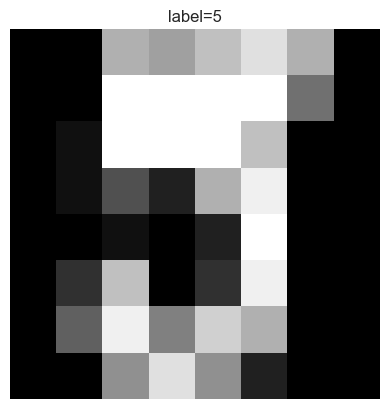

In [2]:
digits=load_digits()
X=digits.images.astype('float32')/16.0
y=digits.target

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Xtr_t=torch.tensor(Xtr).unsqueeze(1)
Xte_t=torch.tensor(Xte).unsqueeze(1)
ytr_t=torch.tensor(ytr, dtype=torch.long)
yte_t=torch.tensor(yte, dtype=torch.long)

train_loader=DataLoader(TensorDataset(Xtr_t,ytr_t), batch_size=64, shuffle=True)

plt.imshow(Xtr[0], cmap='gray'); plt.title(f'label={ytr[0]}'); plt.axis('off'); plt.show()

epoch 1 loss 2.2812068255051323
epoch 2 loss 2.1956743053767993
epoch 3 loss 2.029637186423592
epoch 4 loss 1.6944787554118945
epoch 5 loss 1.2236826964046643
accuracy: 0.8027777777777778


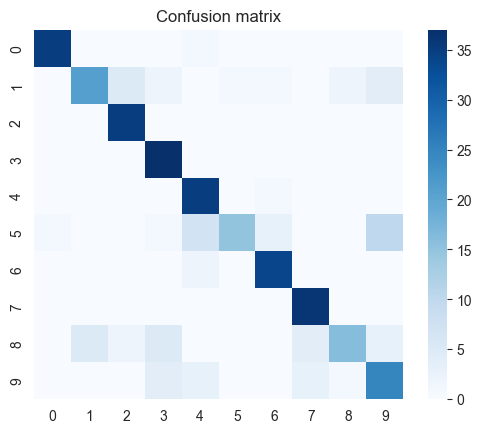

In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc=nn.Linear(32*2*2, 10)
    def forward(self,x):
        x=self.conv(x)
        x=x.view(x.size(0),-1)
        return self.fc(x)

model=SmallCNN().to(device)
opt=torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn=nn.CrossEntropyLoss()

for epoch in range(5):
    model.train(); losses=[]
    for xb,yb in train_loader:
        xb,yb=xb.to(device), yb.to(device)
        opt.zero_grad(); out=model(xb)
        loss=loss_fn(out,yb)
        loss.backward(); opt.step()
        losses.append(loss.item())
    print('epoch', epoch+1, 'loss', float(np.mean(losses)))

model.eval()
with torch.no_grad():
    pred=model(Xte_t.to(device)).cpu().argmax(dim=1).numpy()
acc=(pred==yte).mean()
print('accuracy:', float(acc))

cm=confusion_matrix(yte, pred)
sns.heatmap(cm, cmap='Blues', square=True); plt.title('Confusion matrix'); plt.show()

In [4]:
print('DONE 2026-02-16 03:21:21')

DONE 2026-02-16 03:21:21
